In [ ]:
#1.import requried libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
#2.load dataset

In [7]:
df=pd.read_csv("car data.csv")
print("Data Loaded Successfully\n")

print(df.head())

Data Loaded Successfully

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [ ]:
#3.understand dataset

In [8]:
print("Dataset Shape:",df.shape)
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (301, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Statistical Summary:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   3888

In [ ]:
#4.handling missing values

In [9]:
print("\nMissing values:")
print(df.isnull().sum())
df=df.dropna()

print("\nAfter removing missing values:",df.shape)


Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

After removing missing values: (301, 9)


In [ ]:
#5.handle categorical varibles

In [10]:
categorical_columns=df.select_dtypes(include="object").columns
print("Categorical Columns:",categorical_columns)
df=pd.get_dummies(df,columns=categorical_columns,drop_first=True)
print("\nAfter Encoding:")
print(df.head())

Categorical Columns: Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')

After Encoding:
   Year  Selling_Price  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
0  2014           3.35           5.59       27000      0               False   
1  2013           4.75           9.54       43000      0               False   
2  2017           7.25           9.85        6900      0               False   
3  2011           2.85           4.15        5200      0               False   
4  2014           4.60           6.87       42450      0               False   

   Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
0               False                   False                       False   
1               False                   False                       False   
2               False                   False                       False   
3               False                   False                       False   
4              

In [ ]:
#6.define feature (x-train) & target (y-test)

In [11]:
target_column="Selling_Price"
x=df.drop(columns=[target_column])
y=df[target_column]
print("Features Shape:",x.shape)
print("Target Shape:",y.shape)

Features Shape: (301, 105)
Target Shape: (301,)


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Data Shape:",x_train.shape)
print("Testing Data Shape:",x_test.shape)

Training Data Shape: (240, 105)
Testing Data Shape: (61, 105)


In [ ]:
#8.Train Model

In [13]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

print("Linear Regression Model Trained:")

Linear Regression Model Trained:


In [ ]:
#9.Predict & Evaluate (Linear Regression)

In [14]:
y_pred_lr = lr_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("Linear Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Results:
MAE: 2.036517478988635
MSE: 9.221090391438572
R2 Score: 0.599702348194532


In [15]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train, y_train)
print("Random Forest Model Trained")

Random Forest Model Trained


In [16]:
y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 0.5907950819672131
MSE: 0.7524023742622952
R2 Score: 0.9673373873539192


In [ ]:
#10.Visualization

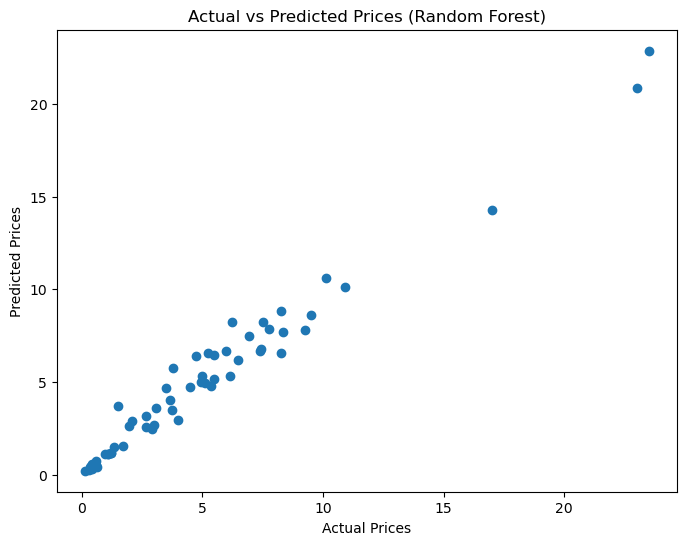

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

In [ ]:
#11.Feature Importance

In [18]:
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                    Feature  Importance
1             Present_Price    0.868146
0                      Year    0.059892
2                Driven_kms    0.031911
91    Car_Name_land cruiser    0.007772
104     Transmission_Manual    0.006167
84        Car_Name_fortuner    0.005540
101        Fuel_Type_Diesel    0.003618
72            Car_Name_city    0.003429
89          Car_Name_innova    0.002788
74   Car_Name_corolla altis    0.002463


In [1]:
print("\n================ FINAL PROJECT SUMMARY ================")


================ FINAL PROJECT SUMMARY ================


In [19]:
# Compare R2 Scores
if r2_rf > r2:
    best_model = "Random Forest Regressor"
    best_r2 = r2_rf
else:
    best_model = "Linear Regression"
    best_r2 = r2

print(f"\nBest Performing Model: {best_model}")
print(f"Best R2 Score: {best_r2}")

print("\nModel Comparison:")
print(f"Linear Regression R2 Score: {r2}")
print(f"Random Forest R2 Score: {r2_rf}")

print("\nBusiness Insights:")
print("1. Present Price is the most important factor affecting Selling Price.")
print("2. Newer cars (higher Year value) tend to have higher resale value.")
print("3. Cars with lower driven kilometers generally sell at better prices.")
print("4. Fuel type and transmission also influence car resale value.")


Best Performing Model: Random Forest Regressor
Best R2 Score: 0.9673373873539192

Model Comparison:
Linear Regression R2 Score: 0.599702348194532
Random Forest R2 Score: 0.9673373873539192

Business Insights:
1. Present Price is the most important factor affecting Selling Price.
2. Newer cars (higher Year value) tend to have higher resale value.
3. Cars with lower driven kilometers generally sell at better prices.
4. Fuel type and transmission also influence car resale value.


In [20]:
print("\nConclusion:")
print("The Random Forest model performed better than Linear Regression")
print("because it captures complex and non-linear relationships in the dataset.")
print("This model can be used to predict used car prices more accurately.")
print("========================================================")


Conclusion:
The Random Forest model performed better than Linear Regression
because it captures complex and non-linear relationships in the dataset.
This model can be used to predict used car prices more accurately.
